# Outlier detection : Lab 5.2.2

Statistical methods on **three variables**: **Income**, **Age**, and **Monthly spend**.  
We use **one method per variable** where it fits the shape of the data (simple rule of thumb in the markdown before each step).

## Step 0 : Imports and synthetic data

- **Age**: mostly bell-shaped → **Z-score** is a reasonable first check.  
- **Income**: here mostly symmetric day-to-day values with a few giant salaries → **IQR** still helps because it resists the pull of those few giants better than a mean-based rule.  
- **Monthly spend**: tied to income but with occasional “spikes” → **Tukey fences** (tunable with \(k\)) highlight extreme spend relative to the bulk of the data.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
n = 200

# Typical ages (roughly normal), plus a few impossible / extreme ages
age = np.random.normal(loc=42, scale=10, size=n)
age = np.clip(age, 22, 68)
age_out = np.array([5, 8, 97, 108])
age = np.concatenate([age, age_out])

# Mostly symmetric incomes, plus a few clearly separate “mega” incomes
income = np.random.normal(loc=52_000, scale=6_000, size=n)
income = np.clip(income, 38_000, 64_000)
income_out = np.array([395_000, 480_000, 720_000, 990_000])
income = np.concatenate([income, income_out])

# Spend loosely follows income, plus a few “overspend” spikes
noise = np.random.normal(0, 400, size=n)
spend = 0.25 * income[:n] + 1200 + noise
spend = np.clip(spend, 200, None)
spend_out = np.array([28_000, 35_000, 52_000, 68_000])
spend = np.concatenate([spend, spend_out])

print("Samples:", len(age), len(income), len(spend))
assert len(age) == len(income) == len(spend)

Samples: 204 204 204


## Step 1 : Quick look (histograms)

**Income** and **Spend** show a long right tail once the rare large values are included; **Age** looks more bell-shaped.

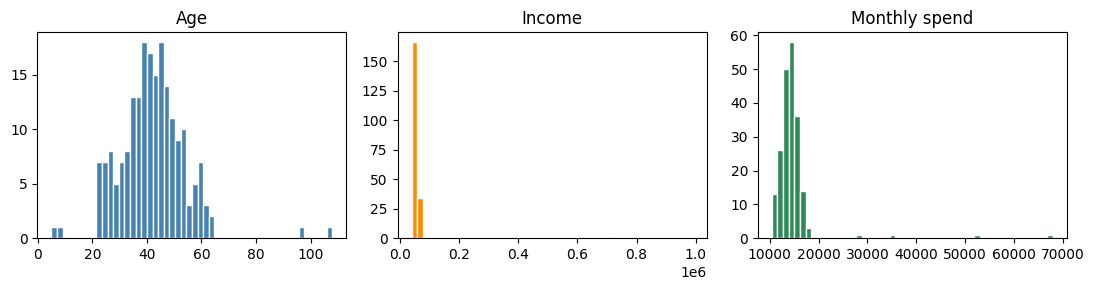

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))
ax[0].hist(age, bins=50, color="steelblue", edgecolor="white")
ax[0].set_title("Age")
ax[1].hist(income, bins=50, color="darkorange", edgecolor="white")
ax[1].set_title("Income")
ax[2].hist(spend, bins=50, color="seagreen", edgecolor="white")
ax[2].set_title("Monthly spend")
plt.tight_layout()
plt.show()

## Step 2 : Z-score on **Age**

For each value: \(z = \dfrac{x - \text{mean}}{\text{std}}\).  
Flag if \(|z|\) is above a threshold (here **2.5**).

Z-score outliers (age): [  5.   8.  97. 108.]


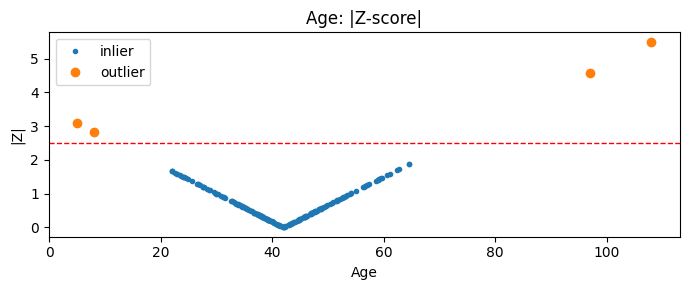

In [6]:
z = np.abs((age - np.mean(age)) / np.std(age))
z_thr = 2.5
mask_age = z > z_thr

print("Z-score outliers (age):", age[mask_age])

plt.figure(figsize=(7, 3))
plt.plot(age[~mask_age], z[~mask_age], ".", label="inlier")
plt.plot(age[mask_age], z[mask_age], "o", label="outlier")
plt.axhline(z_thr, color="red", linestyle="--", linewidth=1)
plt.xlabel("Age")
plt.ylabel("|Z|")
plt.title("Age: |Z-score|")
plt.legend()
plt.tight_layout()
plt.show()

## Step 3 : IQR rule on **Income**

\(Q1\), \(Q3\), \(\text{IQR} = Q3 - Q1\).  
Usual fences: below \(Q1 - 1.5\,\text{IQR}\) or above \(Q3 + 1.5\,\text{IQR}\).

IQR fences: 37020.36934715985 … 67007.59190321255
IQR outliers (income): [395000. 480000. 720000. 990000.]


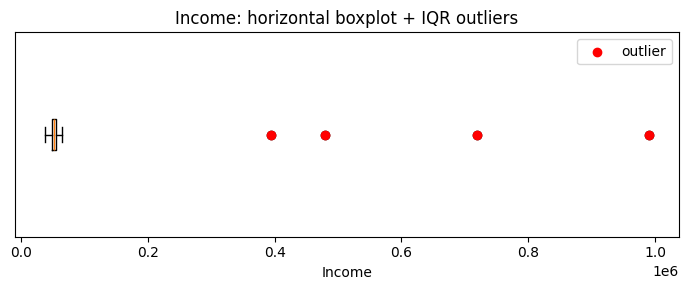

In [7]:
q1, q3 = np.percentile(income, [25, 75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_inc = (income < low) | (income > high)

print("IQR fences:", low, "…", high)
print("IQR outliers (income):", income[mask_inc])

plt.figure(figsize=(7, 3))
plt.boxplot(income, vert=False)
plt.scatter(income[mask_inc], np.ones(mask_inc.sum()), color="red", zorder=3, label="outlier")
plt.xlabel("Income")
plt.title("Income: horizontal boxplot + IQR outliers")
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

## Step 4 : Tukey fences on **Monthly spend**

Same quartiles as IQR, but you choose a multiplier **K** (often 1.5 or **2**).  
Larger **K** → fewer points flagged.

Tukey fences (K=2.0): 9124.964338817748 … 19204.506836397253
Tukey outliers (spend): [28000. 35000. 52000. 68000.]


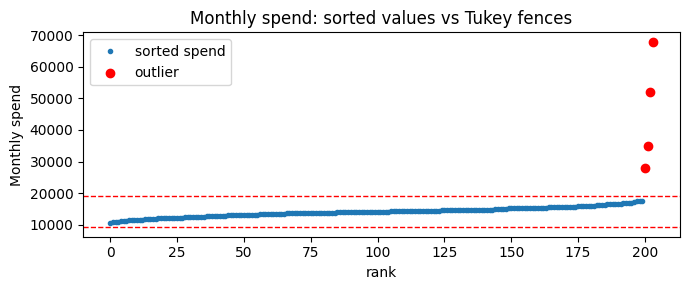

In [8]:
q1, q3 = np.percentile(spend, [25, 75])
iqr = q3 - q1
K = 2.0
low, high = q1 - K * iqr, q3 + K * iqr
mask_sp = (spend < low) | (spend > high)

print("Tukey fences (K=%s):" % K, low, "…", high)
print("Tukey outliers (spend):", spend[mask_sp])

order = np.argsort(spend)
x = np.arange(len(spend))
plt.figure(figsize=(7, 3))
plt.plot(x, spend[order], ".", label="sorted spend")
plt.axhline(low, color="red", linestyle="--", linewidth=1)
plt.axhline(high, color="red", linestyle="--", linewidth=1)
plt.scatter(x[mask_sp[order]], spend[order][mask_sp[order]], color="red", zorder=3, label="outlier")
plt.xlabel("rank")
plt.ylabel("Monthly spend")
plt.title("Monthly spend: sorted values vs Tukey fences")
plt.legend()
plt.tight_layout()
plt.show()

## Exercise (optional)

1. Run **Z-score** on **Income** and **IQR** on **Age**. Compare counts, why can they disagree?  
2. Change **K** in Tukey (e.g. 1.5 vs 3) for **spend** and note how many points are flagged.  
3. Plot **spend** vs **income** with outliers highlighted (2D view of joint behaviour).